In [9]:
import os
import numpy as np
import nibabel as nib
from scipy.fft import fft
from scipy.signal import detrend, correlate
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import cv2
import pandas as pd

In [31]:
from IPython.display import clear_output
import matplotlib.pyplot as plt

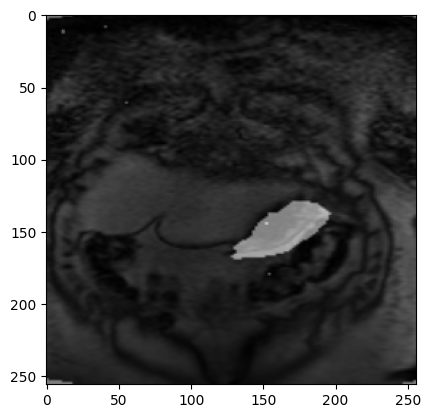

In [49]:
# --- Load NIfTI file ---
nifti_file = '/home/miguel/GI/2 - Reconstruction/Reconstructed-4D-original/FD_027/FD_027_4D_reconstructed.nii'
img = nib.load(nifti_file)
data = img.get_fdata()
num_rows, num_cols, num_slices, num_time_frames = data.shape
print('Size of data:', data.shape)  # (256, 256, Slices, TimeFrames)

# --- Cross-Sectional Area Changes ---
cross_sectional_areas = np.zeros((num_slices, num_time_frames), dtype=np.float64)

for z in range(1, num_slices + 1):
    z = 10
    slice_nonzero_history = []
    for t in range(1, num_time_frames+1)[:10]:

        path = f'/home/miguel/GI/0 - Data Exploration & Analysis/GI-Roberta/gi-roberta-dataset/all-cine-mri-pngs-corrected/FD_027_time_{t}_slice_{z}_mask.png'
        image_path = f'/home/miguel/GI/0 - Data Exploration & Analysis/GI-Roberta/gi-roberta-dataset/all-cine-mri-pngs-corrected/FD_027_time_{t}_slice_{z}_image.png'

        # slice_img = data[:, :, z, t]
        slice_img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        fig, ax = plt.subplots()
        ax.imshow(slice_img, cmap='gray')
        ax.imshow(img.astype(np.uint8), cmap='gray', alpha=0.5)
        plt.show()
        clear_output(wait=True)
        plt.close(fig)

        # Clear the output
        

        if slice_img is None:
            print(f"Error reading image at {path}. Skipping this slice.")
            continue

            
        slice_nonzero_history.append(np.count_nonzero(slice_img))
    if np.sum(slice_nonzero_history) > 0:
        break

In [29]:
img

In [6]:
slice_img

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)